In [186]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
import time
from datetime import datetime

t_inicio = time.time()
ruta_resultados = "C:/Users/inesm/OneDrive/Documentos/tfg/ModeloFriedkin/resultados_2026-02-28_135839/resultados.csv"

df = pd.read_csv(ruta_resultados)
df.describe()

,replica,fracTrolls,lambda,rango_final,std_final,median_final,mean_final,prop_neg,median_norm,resid,t_conv,rho_lambdaW,nSCC
count,16200.000000,16200.000000,16200.000000,16200.000000,16200.000000,16200.000000,16200.000000,16200.000000,16200.000000,1.620000e+04,16200.000000,16200.000000,16200.000000
mean,25.500000,0.150000,0.475000,1.470201,0.437650,0.288709,0.141405,0.151139,0.342428,5.786057e-07,17.327407,0.409499,7.286667
std,14.431315,0.102473,0.256182,0.492573,0.175180,0.274310,0.305782,0.290909,0.264028,2.603633e-07,14.351172,0.230957,8.824736
min,1.000000,0.000000,0.100000,0.151724,0.040214,-0.681671,-0.710558,0.000000,-0.590772,2.389480e-08,3.000000,0.035411,1.000000
25%,13.000000,0.060000,0.250000,1.183449,0.328985,0.165996,-0.048400,0.000000,0.233756,3.732961e-07,8.000000,0.221168,1.000000
50%,25.500000,0.150000,0.475000,1.670580,0.454815,0.371371,0.156988,0.010638,0.452509,5.995635e-07,12.000000,0.398109,2.000000
75%,38.000000,0.240000,0.700000,1.857314,0.575216,0.496455,0.391104,0.113475,0.538517,8.045646e-07,22.000000,0.592817,16.000000
max,50.000000,0.300000,0.850000,1.990098,0.744143,0.585048,0.580928,1.000000,0.600115,9.999327e-07,80.000000,0.850000,32.000000


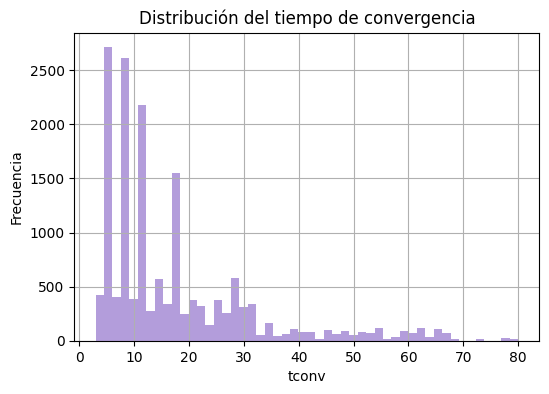

In [187]:
# Histograma para tiempo de convergencia 

plt.figure(figsize=(6,4))
plt.hist(df["t_conv"], bins=50, color='#B39DDB')
plt.xlabel("tconv")
plt.ylabel("Frecuencia")
plt.title("Distribución del tiempo de convergencia")
plt.grid(True)
plt.show()



<Figure size 640x480 with 0 Axes>

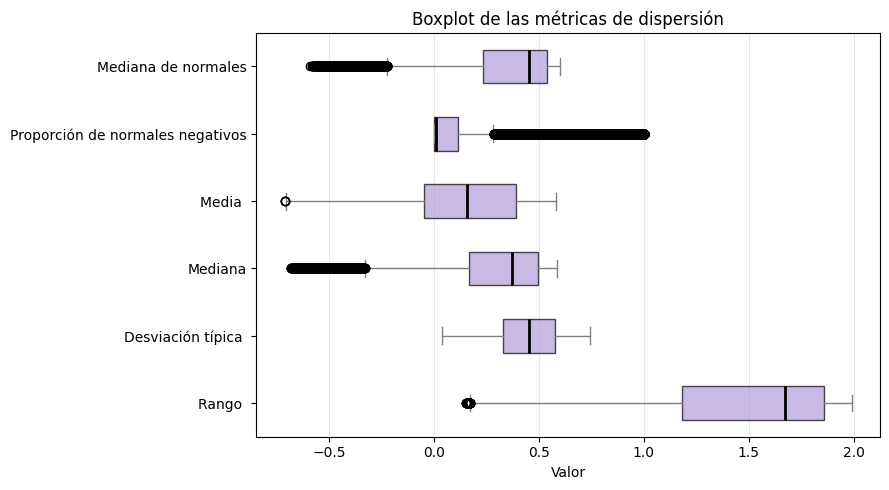

In [188]:
variables_graficar = [
    "rango_final", "std_final", "median_final", "mean_final",
    "prop_neg", "median_norm"
]

labels = [
    "Rango ",
    "Desviación típica ",
    "Mediana",
    "Media ",
    "Proporción de normales negativos",
    "Mediana de normales",
]
plt.tight_layout()
plt.show()
plt.figure(figsize=(9, 5))

plt.boxplot(
    df[variables_graficar],
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor='#B39DDB', alpha=0.7),
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(color='gray'),
    capprops=dict(color='gray')
)

plt.yticks(
    ticks=range(1, len(labels) + 1),
    labels=labels
)
plt.xlabel("Valor")
plt.title("Boxplot de las métricas de dispersión")
plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()



Resultados tabulares

In [189]:
metricas_clave = ['rango_final', 'std_final', 'median_final', 'mean_final', 'prop_neg',
       'median_norm', 't_conv', 'rho_lambdaW', 'nSCC']

In [190]:
tabla = df.groupby("regimen", observed=True)[metricas_clave].agg(["median", "std"]).round(3)
tabla.reindex(["desconectada", "umbral", "fuerte"])

rango_final        std_final        median_final         \
                  median    std    median    std       median    std   
regimen                                                                
desconectada       1.750  0.476     0.493  0.177        0.395  0.276   
umbral             1.664  0.491     0.449  0.174        0.361  0.274   
fuerte             1.576  0.500     0.435  0.173        0.352  0.272   

             mean_final        prop_neg        median_norm        t_conv  \
                 median    std   median    std      median    std median   
regimen                                                                    
desconectada      0.167  0.299    0.022  0.259       0.475  0.256   13.0   
umbral            0.153  0.307    0.012  0.290       0.448  0.264   12.0   
fuerte            0.148  0.311    0.000  0.320       0.428  0.270   11.0   

                     rho_lambdaW          nSCC         
                 std      median    std median    std  
regimen                                                
desconectada  16.192       0.398  0.238   19.0  5.233  
umbral        13.595       0.398  0.229    2.0  0.864  
fuerte        12.869       0.397  0.226    1.0  0.000

In [191]:
tabla = df.groupby("loc")[metricas_clave].agg(["median", "std"]).round(3)
tabla.reindex(["bajo_pr", "medio_pr", "alto_pr"])

rango_final        std_final        median_final        mean_final  \
              median    std    median    std       median    std     median   
loc                                                                           
bajo_pr        1.726  0.484     0.503  0.180        0.423  0.190      0.221   
medio_pr       1.674  0.489     0.451  0.172        0.355  0.268      0.146   
alto_pr        1.584  0.498     0.412  0.170        0.299  0.323      0.099   

                prop_neg        median_norm        t_conv         rho_lambdaW  \
            std   median    std      median    std median     std      median   
loc                                                                             
bajo_pr   0.250    0.004  0.192       0.500  0.181   12.0  17.097       0.413   
medio_pr  0.303    0.014  0.288       0.443  0.256   12.0  14.116       0.400   
alto_pr   0.344    0.038  0.347       0.385  0.313   12.0  10.799       0.361   

                  nSCC         
            std median    std  
loc                            
bajo_pr   0.241    2.0  8.825  
medio_pr  0.230    2.0  8.825  
alto_pr   0.215    2.0  8.825

In [192]:
df.groupby("lambda")[metricas_clave].agg(["median", "std"]).round(3)

rango_final        std_final        median_final        mean_final  \
            median    std    median    std       median    std     median   
lambda                                                                      
0.10         1.942  0.385     0.585  0.162        0.481  0.075      0.299   
0.25         1.863  0.402     0.558  0.162        0.441  0.102      0.266   
0.40         1.773  0.418     0.529  0.159        0.393  0.139      0.216   
0.55         1.644  0.430     0.489  0.154        0.329  0.191      0.132   
0.70         1.442  0.437     0.403  0.146        0.197  0.265      0.014   
0.85         1.048  0.425     0.300  0.129       -0.073  0.372     -0.190   

              prop_neg        median_norm        t_conv         rho_lambdaW  \
          std   median    std      median    std median     std      median   
lambda                                                                        
0.10    0.170    0.000  0.006       0.543  0.024    5.0   0.369       0.089   
0.25    0.191    0.004  0.018       0.506  0.055    8.0   0.847       0.222   
0.40    0.220    0.008  0.047       0.455  0.100   12.0   1.624       0.357   
0.55    0.258    0.024  0.120       0.372  0.156   17.0   3.136       0.490   
0.70    0.313    0.091  0.293       0.233  0.236   25.0   6.552       0.620   
0.85    0.395    0.598  0.432      -0.037  0.354   40.0  17.261       0.757   

                nSCC         
          std median    std  
lambda                       
0.10    0.013    2.0  8.826  
0.25    0.031    2.0  8.826  
0.40    0.050    2.0  8.826  
0.55    0.069    2.0  8.826  
0.70    0.088    2.0  8.826  
0.85    0.107    2.0  8.826

In [193]:
df.groupby("fracTrolls")[metricas_clave].agg(["median", "std"]).round(3)

rango_final        std_final        median_final        mean_final  \
                median    std    median    std       median    std     median   
fracTrolls                                                                      
0.00             0.618  0.241     0.150  0.068        0.559  0.007      0.548   
0.06             1.797  0.199     0.389  0.044        0.481  0.131      0.391   
0.12             1.769  0.263     0.492  0.074        0.399  0.207      0.242   
0.18             1.739  0.304     0.551  0.103        0.320  0.251      0.111   
0.24             1.712  0.337     0.586  0.127        0.250  0.277      0.003   
0.30             1.684  0.362     0.604  0.146        0.161  0.289     -0.113   

                  prop_neg        median_norm        t_conv          \
              std   median    std      median    std median     std   
fracTrolls                                                            
0.00        0.005    0.000  0.000       0.559  0.007    8.0   7.797   
0.06        0.131    0.004  0.079       0.495  0.136   15.0  18.836   
0.12        0.190    0.011  0.262       0.431  0.214   15.0  15.774   
0.18        0.213    0.033  0.320       0.377  0.262   14.0  13.947   
0.24        0.222    0.061  0.348       0.337  0.295   13.0  12.694   
0.30        0.220    0.093  0.370       0.289  0.319   12.0  11.687   

           rho_lambdaW          nSCC         
                median    std median    std  
fracTrolls                                   
0.00             0.475  0.256    2.0  8.826  
0.06             0.436  0.242    2.0  8.826  
0.12             0.400  0.229    2.0  8.826  
0.18             0.386  0.218    2.0  8.826  
0.24             0.359  0.209    2.0  8.826  
0.30             0.339  0.202    2.0  8.826

Gráficas

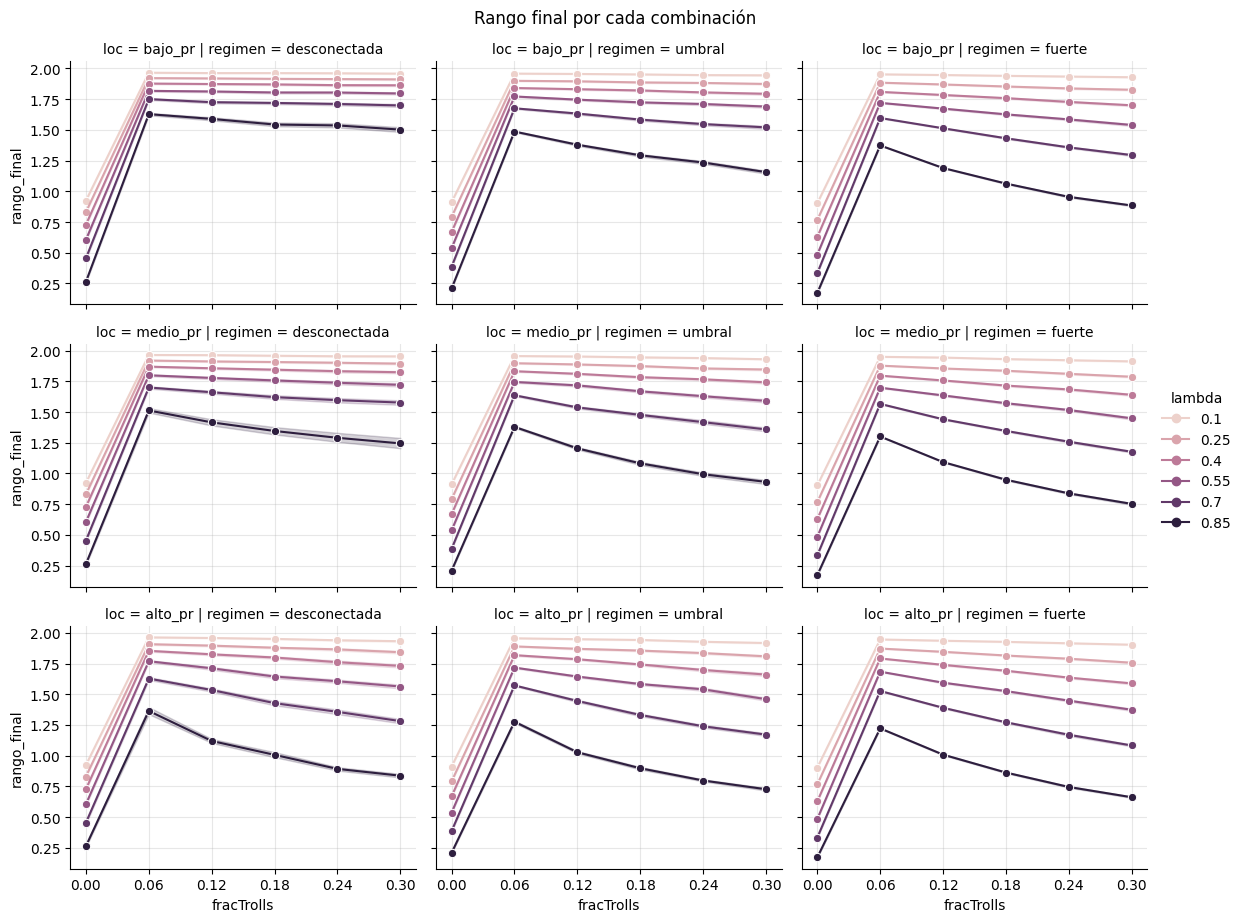

In [194]:
g= sns.relplot(
    data=df,
    x="fracTrolls",
    y="rango_final",
    col="regimen",
    row="loc",
    hue= "lambda",
    kind="line",
    marker= "o",
    height=3,
    aspect=1.3
)
xticks = sorted(df["fracTrolls"].unique())

for ax in g.axes.flat:
    ax.set_xticks(xticks)
    ax.grid(True, which="major", axis="both", alpha=0.3)
    ax.set_axisbelow(True)

plt.suptitle("Rango final por cada combinación", y=1.02)
plt.show()


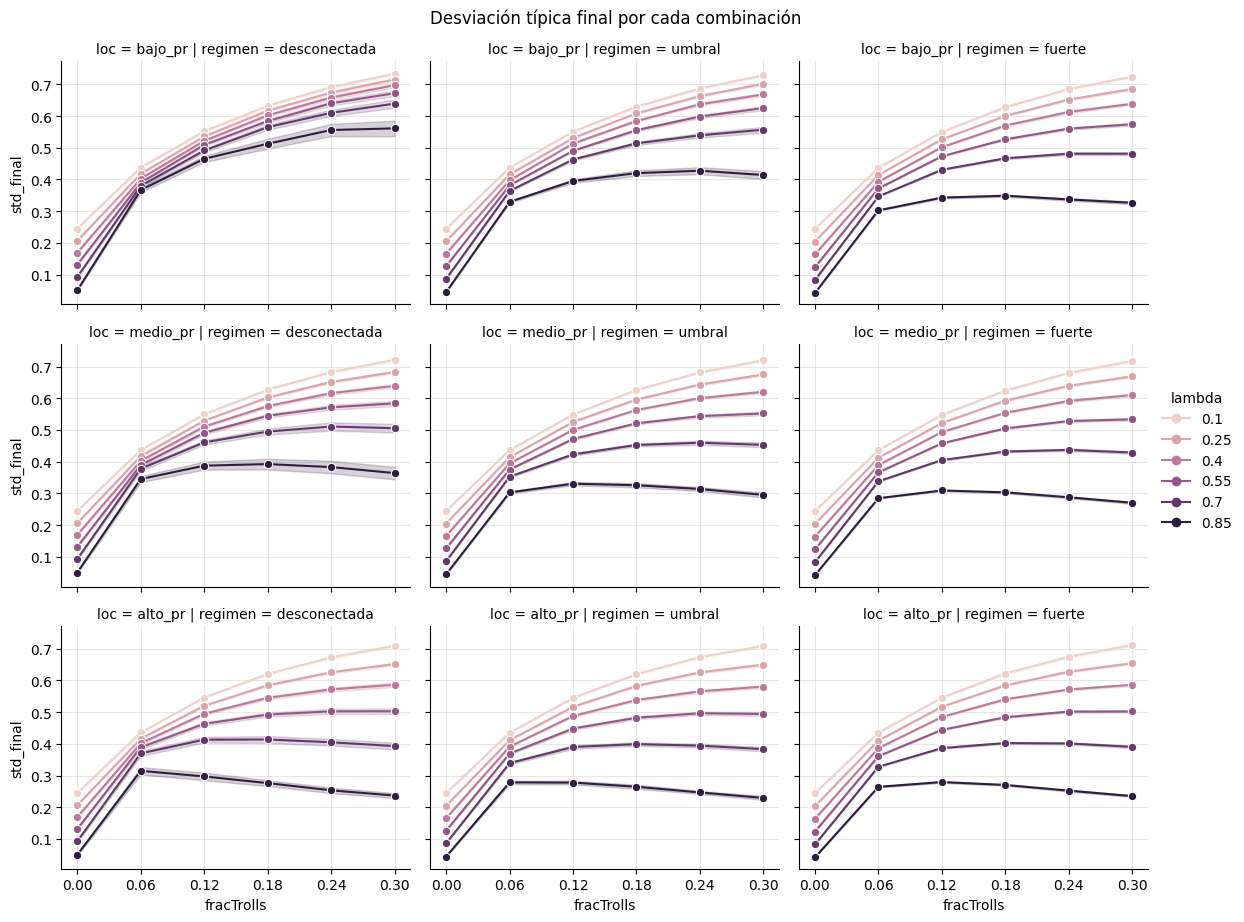

In [195]:
g= sns.relplot(
    data=df,
    x="fracTrolls",
    y="std_final",
    col="regimen",
    row="loc",
    errorbar= "sd",
    hue= "lambda",
    kind="line",
    marker= "o",
    height=3,
    aspect=1.3
)
xticks = sorted(df["fracTrolls"].unique())

for ax in g.axes.flat:
    ax.set_xticks(xticks)
    ax.grid(True, which="major", axis="both", alpha=0.3)
    ax.set_axisbelow(True)

plt.suptitle("Desviación típica final por cada combinación", y=1.02)
plt.show()

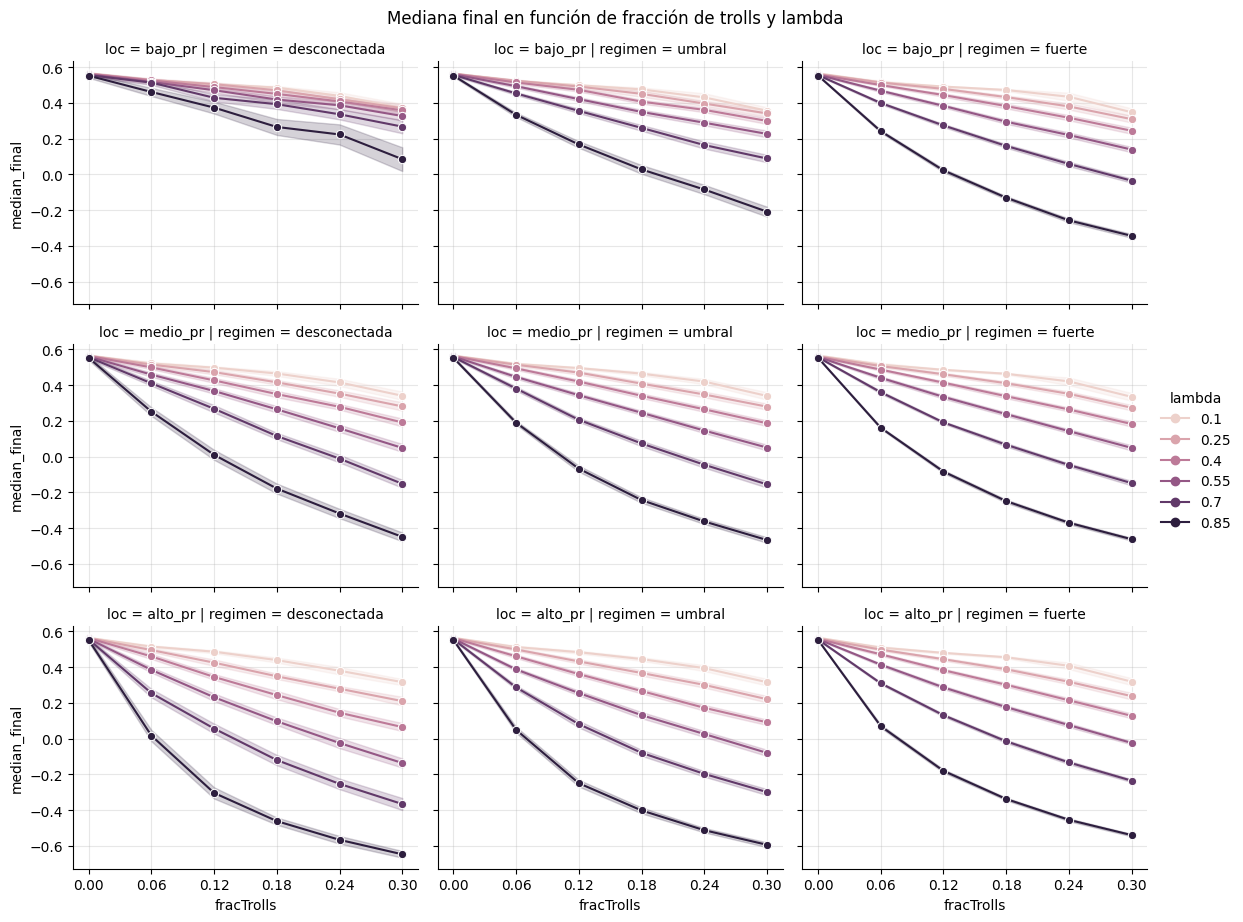

In [196]:
g= sns.relplot(
    data=df,
    x="fracTrolls",
    y="median_final",
    col="regimen",
    row="loc",
    errorbar= "sd",
    hue= "lambda",
    kind="line",
    marker= "o",
    height=3,
    aspect=1.3
)
xticks = sorted(df["fracTrolls"].unique())

for ax in g.axes.flat:
    ax.set_xticks(xticks)
    ax.grid(True, which="major", axis="both", alpha=0.3)
    ax.set_axisbelow(True)

plt.suptitle("Mediana final en función de fracción de trolls y lambda", y=1.02)
plt.show()

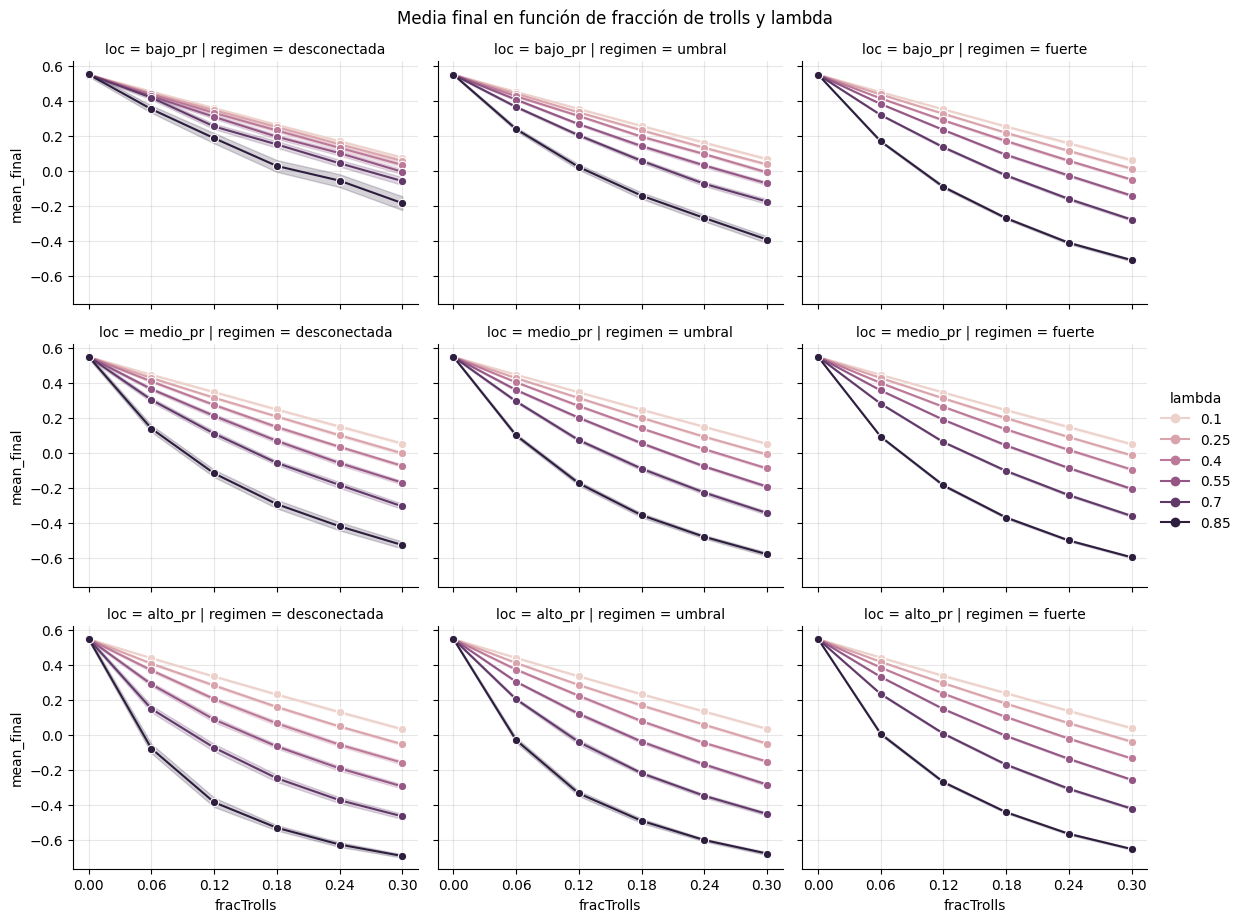

In [197]:
g= sns.relplot(
    data=df,
    x="fracTrolls",
    y="mean_final",
    col="regimen",
    row="loc",
    hue= "lambda",
    errorbar="sd",
    kind="line",
    marker= "o",
    height=3,
    aspect=1.3
)
xticks = sorted(df["fracTrolls"].unique())

for ax in g.axes.flat:
    ax.set_xticks(xticks)
    ax.grid(True, which="major", axis="both", alpha=0.3)
    ax.set_axisbelow(True)

plt.suptitle("Media final en función de fracción de trolls y lambda", y=1.02)
plt.show()

In [ ]:
g= sns.relplot(
    data=df,
    x="fracTrolls",
    y="prop_neg",
    col="regimen",
    row="loc",
    hue= "lambda",
    errorbar="sd",
    kind="line",
    marker= "o",
    height=3,
    aspect=1.3
)
xticks = sorted(df["fracTrolls"].unique())

for ax in g.axes.flat:
    ax.set_xticks(xticks)
    ax.grid(True, which="major", axis="both", alpha=0.3)
    ax.set_axisbelow(True)

plt.suptitle("Mediana final en función de fracción de trolls y lambda", y=1.02)
plt.show()

modelos

In [ ]:
# Convertir categóricas 
df["regimen"] = df["regimen"].astype("category")
df["loc"] = df["loc"].astype("category")
df = df.rename(columns={"lambda": "lam"})


In [ ]:
# Modelo para la varianza
model_var = smf.ols("std_final ~ fracTrolls + lam + C(regimen) + C(loc)", data=df).fit(cov_type="HC1")
X_var = model_var.model.exog
vif_var = pd.DataFrame()
vif_var["variable"] = model_var.model.exog_names
vif_var["VIF"] = [variance_inflation_factor(X_var, i) for i in range(X_var.shape[1])]

# Modelo para el rango
model_rango = smf.ols("rango_final ~ fracTrolls + lam + C(regimen) + C(loc)", data=df).fit(cov_type="HC1")
X_rango = model_rango.model.exog
vif_rango = pd.DataFrame()
vif_rango["variable"] = model_rango.model.exog_names
vif_rango["VIF"] = [variance_inflation_factor(X_rango, i) for i in range(X_rango.shape[1])]

# Modelo para la mediana
model_median = smf.ols("median_final ~ fracTrolls + lam + C(regimen) + C(loc)", data=df).fit(cov_type="HC1")
X_median = model_rango.model.exog
vif_median = pd.DataFrame()
vif_median["variable"] = model_median.model.exog_names
vif_median["VIF"] = [variance_inflation_factor(X_median, i) for i in range(X_median.shape[1])]

# Modelo para la media
model_mean = smf.ols("mean_final ~ fracTrolls + lam + C(regimen) + C(loc)", data=df).fit(cov_type="HC1")
X_mean = model_mean.model.exog
vif_mean = pd.DataFrame()
vif_mean["variable"] = model_mean.model.exog_names
vif_mean["VIF"] = [variance_inflation_factor(X_mean, i) for i in range(X_mean.shape[1])]

# Modelo para la proporción de normales negativos 
model_prop_neg = smf.ols("prop_neg ~ fracTrolls + lam + C(regimen) + C(loc)", data=df).fit(cov_type="HC1")
X_prop_neg = model_prop_neg.model.exog
vif_prop_neg = pd.DataFrame()
vif_prop_neg["variable"] = model_prop_neg.model.exog_names
vif_prop_neg["VIF"] = [variance_inflation_factor(X_prop_neg, i) for i in range(X_prop_neg.shape[1])]

# Modelo para la mediana de normales
model_median_norm = smf.ols("median_norm ~ fracTrolls + lam + C(regimen) + C(loc)", data=df).fit(cov_type="HC1")
X_median_norm = model_median_norm.model.exog
vif_median_norm = pd.DataFrame()
vif_median_norm["variable"] = model_median_norm.model.exog_names
vif_median_norm["VIF"] = [variance_inflation_factor(X_median_norm, i) for i in range(X_median_norm.shape[1])]


In [ ]:
print(model_var.summary())
print(vif_var)

print(model_mean.summary())
print(vif_mean)

print(model_median.summary())
print(vif_median)

print(model_rango.summary())
print(vif_rango)

print(model_prop_neg.summary())
print(vif_prop_neg)

print(model_median_norm.summary())
print(vif_median_norm)

                            OLS Regression Results                            
Dep. Variable:              std_final   R-squared:                       0.790
Model:                            OLS   Adj. R-squared:                  0.790
Method:                 Least Squares   F-statistic:                 1.392e+04
Date:                Sat, 28 Feb 2026   Prob (F-statistic):               0.00
Time:                        14:20:07   Log-Likelihood:                 17886.
No. Observations:               16200   AIC:                        -3.576e+04
Df Residuals:                   16193   BIC:                        -3.570e+04
Df Model:                           6                                         
Covariance Type:                  HC1                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                0.3954 

In [ ]:
t_fin = time.time()
duracion_total = t_fin - t_inicio

segundos = int(duracion_total % 60)

print(f"Tiempo total de ejecución: {segundos} seg")

Tiempo total de ejecución: 22 seg
